# Chronological Train / Validation / Test Split

## Objective

This notebook establishes the chronological experimental data split for
the M5 retail demand forecasting problem.

Because retail demand forecasting is a time-series problem, observations
must remain in chronological order.

The dataset will be divided into:

- 80% Training
- 10% Validation
- 10% Test

The exact boundaries are calculated directly from the M5 calendar and sales
data.

## Experimental Protocol

Training data is used to learn model parameters.

Validation data is used for:
- Hyperparameter tuning
- Model configuration selection
- Early stopping

Test data is kept completely unseen during model development and is used
only for final model evaluation.

No random shuffling is used because it would violate the temporal structure
of the forecasting problem.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if 'google.colab' in sys.modules:
    BASE = Path("/content")
else:
    BASE = Path("..").resolve()

sys.path.insert(0, str(BASE / "src"))


In [2]:
PROCESSED_PATH = BASE / "data" / "m5" / "processed"
RESULTS_PATH = BASE / "results"

RESULTS_PATH.mkdir(
    parents=True,
    exist_ok=True
)

In [3]:
calendar_clean = pd.read_csv(
    PROCESSED_PATH / "calendar_clean.csv"
)

sales_clean = pd.read_csv(
    PROCESSED_PATH / "sales_train_validation_clean.csv"
)

calendar_clean["date"] = pd.to_datetime(
    calendar_clean["date"]
)

print("Calendar shape:", calendar_clean.shape)
print("Sales shape:", sales_clean.shape)

Calendar shape: (1969, 14)
Sales shape: (30490, 1919)


In [4]:
sales_columns = [
    column
    for column in sales_clean.columns
    if column.startswith("d_")
]

print("Number of sales days:", len(sales_columns))
print("First day:", sales_columns[0])
print("Last day:", sales_columns[-1])

Number of sales days: 1913
First day: d_1
Last day: d_1913


In [5]:
calendar_sales = calendar_clean[
    calendar_clean["d"].isin(sales_columns)
].copy()

calendar_sales = calendar_sales.sort_values(
    "date"
).reset_index(drop=True)

print(
    "Calendar rows matching sales days:",
    len(calendar_sales)
)

Calendar rows matching sales days: 1913


In [6]:
assert len(calendar_sales) == len(sales_columns)

assert calendar_sales["date"].is_monotonic_increasing

assert calendar_sales["d"].tolist() == sales_columns

print("Sales-day to calendar-date mapping validated.")

Sales-day to calendar-date mapping validated.


In [7]:
print(
    "Dataset start:",
    calendar_sales["date"].min()
)

print(
    "Dataset end:",
    calendar_sales["date"].max()
)

display(calendar_sales[
    ["d", "date"]
].head())

display(calendar_sales[
    ["d", "date"]
].tail())

Dataset start: 2011-01-29 00:00:00
Dataset end: 2016-04-24 00:00:00


,d,date
0,d_1,2011-01-29
1,d_2,2011-01-30
2,d_3,2011-01-31
3,d_4,2011-02-01
4,d_5,2011-02-02


,d,date
1908,d_1909,2016-04-20
1909,d_1910,2016-04-21
1910,d_1911,2016-04-22
1911,d_1912,2016-04-23
1912,d_1913,2016-04-24


In [8]:
import importlib
import data_splitting

importlib.reload(
    data_splitting
)

from data_splitting import (
    get_sales_columns,
    create_chronological_split,
    validate_chronological_split,
    create_split_summary
)

In [9]:
split = create_chronological_split(
    sales_clean,
    train_ratio=0.80,
    validation_ratio=0.10
)

print(
    "Training days:",
    split["train_days"]
)

print(
    "Validation days:",
    split["validation_days"]
)

print(
    "Test days:",
    split["test_days"]
)

Training days: 1530
Validation days: 191
Test days: 192


In [10]:
print(
    "TRAIN:",
    split["train"][0],
    "→",
    split["train"][-1]
)

print(
    "VALIDATION:",
    split["validation"][0],
    "→",
    split["validation"][-1]
)

print(
    "TEST:",
    split["test"][0],
    "→",
    split["test"][-1]
)

TRAIN: d_1 → d_1530
VALIDATION: d_1531 → d_1721
TEST: d_1722 → d_1913


In [11]:
date_lookup = dict(
    zip(
        calendar_sales["d"],
        calendar_sales["date"]
    )
)

split_summary = create_split_summary(
    split,
    date_lookup
)

display(split_summary)

,split,start_day,end_day,start_date,end_date,number_of_days
0,train,d_1,d_1530,2011-01-29,2015-04-07,1530
1,validation,d_1531,d_1721,2015-04-08,2015-10-15,191
2,test,d_1722,d_1913,2015-10-16,2016-04-24,192


In [12]:
split_validation = validate_chronological_split(
    split
)

for key, value in split_validation.items():
    print(f"{key}: {value}")

train_days: 1530
validation_days: 191
test_days: 192
train_validation_overlap: 0
train_test_overlap: 0
validation_test_overlap: 0
train_before_validation: True
validation_before_test: True
split_valid: True


In [13]:
assert split_validation["split_valid"] is True

assert (
    split["train_days"]
    + split["validation_days"]
    + split["test_days"]
    == 1913
)

print(
    "Chronological split validation passed."
)

Chronological split validation passed.


In [14]:
combined_days = (
    split["train"]
    + split["validation"]
    + split["test"]
)

assert combined_days == sales_columns

print(
    "All 1913 sales days are assigned exactly once."
)

All 1913 sales days are assigned exactly once.


In [15]:
assert (
    split["train"][-1]
    < split["validation"][0]
)

assert (
    split["validation"][-1]
    < split["test"][0]
)

print(
    "Temporal ordering validated:"
)

print(
    "TRAIN < VALIDATION < TEST"
)

Temporal ordering validated:
TRAIN < VALIDATION < TEST


In [16]:
print("TRAIN")
print(
    date_lookup[split["train"][0]],
    "→",
    date_lookup[split["train"][-1]]
)

print()

print("VALIDATION")
print(
    date_lookup[split["validation"][0]],
    "→",
    date_lookup[split["validation"][-1]]
)

print()

print("TEST")
print(
    date_lookup[split["test"][0]],
    "→",
    date_lookup[split["test"][-1]]
)

TRAIN
2011-01-29 00:00:00 → 2015-04-07 00:00:00

VALIDATION
2015-04-08 00:00:00 → 2015-10-15 00:00:00

TEST
2015-10-16 00:00:00 → 2016-04-24 00:00:00


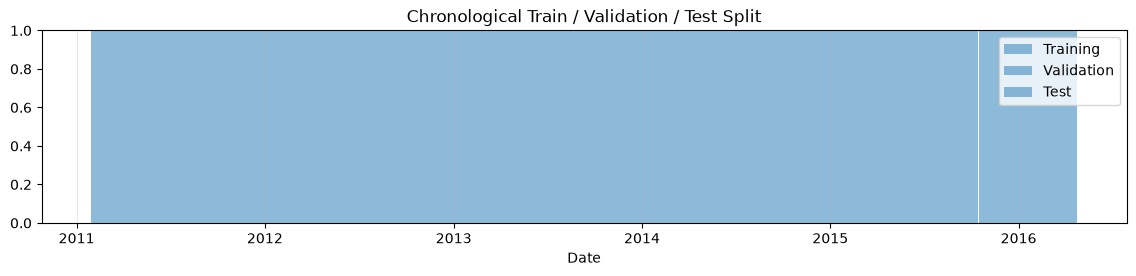

In [17]:
train_start = date_lookup[
    split["train"][0]
]

train_end = date_lookup[
    split["train"][-1]
]

validation_start = date_lookup[
    split["validation"][0]
]

validation_end = date_lookup[
    split["validation"][-1]
]

test_start = date_lookup[
    split["test"][0]
]

test_end = date_lookup[
    split["test"][-1]
]

plt.figure(figsize=(14, 2.5))

plt.axvspan(
    train_start,
    train_end,
    alpha=0.5,
    label="Training"
)

plt.axvspan(
    validation_start,
    validation_end,
    alpha=0.5,
    label="Validation"
)

plt.axvspan(
    test_start,
    test_end,
    alpha=0.5,
    label="Test"
)

plt.xlabel("Date")
plt.title(
    "Chronological Train / Validation / Test Split"
)

plt.legend()
plt.grid(
    axis="x",
    alpha=0.3
)

plt.show()

In [18]:
split_summary.to_csv(
    RESULTS_PATH /
    "chronological_split_summary.csv",
    index=False
)

print(
    "Saved chronological_split_summary.csv"
)

Saved chronological_split_summary.csv


In [19]:
split_validation_df = pd.DataFrame(
    list(split_validation.items()),
    columns=[
        "validation_check",
        "value"
    ]
)

split_validation_df.to_csv(
    RESULTS_PATH /
    "chronological_split_validation.csv",
    index=False
)

print(
    "Saved chronological_split_validation.csv"
)

Saved chronological_split_validation.csv


## Why Chronological Splitting Is Required

This project predicts future retail demand from historical observations.

Randomly shuffling the observations before splitting could place future
observations in the training set while earlier observations remain in the
validation or test set.

This would not represent the real forecasting scenario and could provide
an overly optimistic estimate of temporal generalization.

Therefore, the dataset is divided chronologically:

    Past → Future

Training contains the earliest period, validation contains the subsequent
period, and testing contains the final unseen period.

No temporal overlap exists between the three sets.

## Test Set Isolation

The test period is reserved exclusively for final evaluation.

It will not be used during:

- Hyperparameter tuning
- Learning-rate selection
- Batch-size selection
- Epoch selection
- Early stopping
- Architecture selection
- Feature selection
- Model selection
- Scaler fitting

Training and validation data are the only data available during model
development.

The test set will remain locked until the final experiment.

## Relationship with Preprocessing

The chronological split is established before fitting any data-dependent
preprocessing transformation.

Feature construction performed before this split is causal:

- Lag features use only previous observations.
- Rolling features use only previous observations through shift(1).

However, transformations such as normalization or standardization can learn
parameters from the data. Therefore, their parameters must be fitted using
training data only.

Train-only scaling and leakage validation will be implemented in the next steps.

## Conclusion

A chronological 80/10/10 train/validation/test partition was successfully
created for the 1,913 available M5 demand days.

The resulting partition contains:

- 1,530 training days
- 191 validation days
- 192 test days

The three partitions are mutually exclusive, cover the complete temporal
dataset, and preserve chronological ordering.

The test period is now treated as an unseen future period and will not be
used for model-development decisions.

The next step will implement train-only scaling and explicit leakage
validation before model-ready sequences are generated.